<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Categorical Cross-Entropy Loss**


In this lab, we will use the MNIST handwritten digits dataset to understand **categorical cross-entropy loss**.

The inserted image below introduces two related ideas: **entropy** and **cross-entropy**. Entropy measures the uncertainty inside one probability distribution. If a distribution is spread across many classes, entropy is higher. If most probability is placed on one class, entropy is lower.

Cross-entropy compares two distributions: the true label distribution $p$ and the model's predicted distribution $q$. In classification, the true label is usually one-hot encoded, so cross-entropy mainly depends on the probability that the model assigns to the correct class.

The key difference is simple: **entropy measures uncertainty in the true distribution**, while **cross-entropy measures how well the predicted distribution matches the true distribution**.

If the model gives a high probability to the correct class, the cross-entropy loss is small. If it gives a low probability to the correct class, especially with high confidence in a wrong class, the loss is large. This is why categorical cross-entropy is useful for training multi-class classifiers such as digit recognition models.

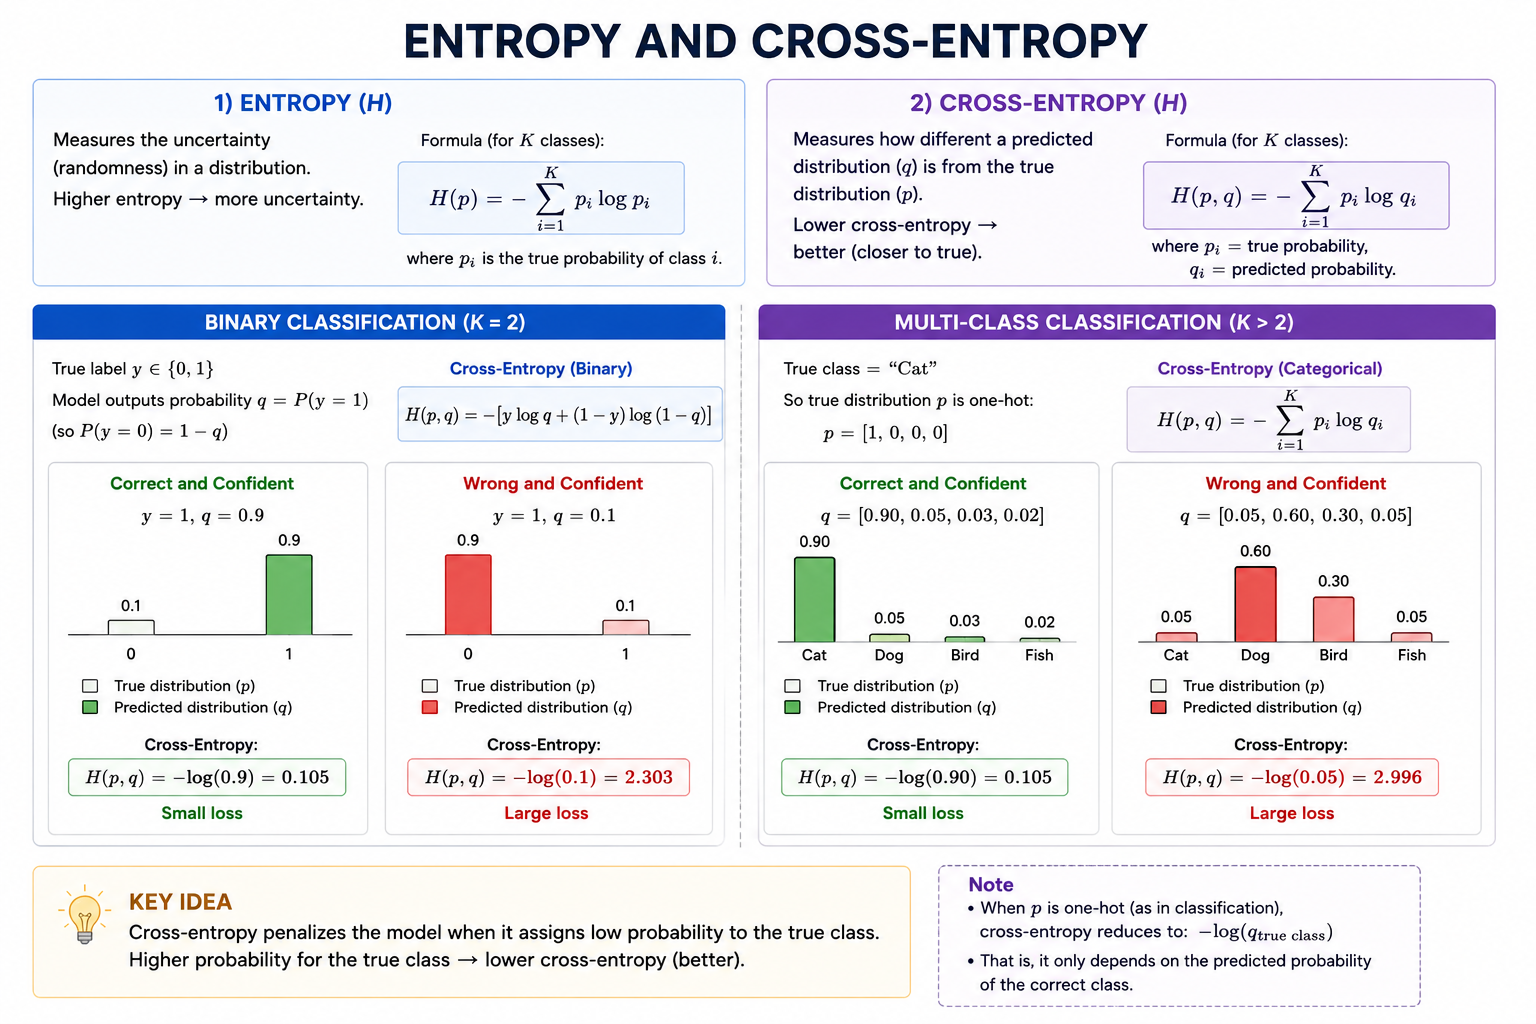


## **House Number Detection**

You have been tasked with building a model that can recognize house numbers from arbitrary street-view images. You are given a set of images of single-digit house numbers engraved into slates or wall surfaces. The images vary in size and color. In this lab, we are going to use the MNIST hand-written digits dataset as a motivating example to understand the __softmax function__, __one-hot encoding__, and __categorical cross-entropy loss (log loss)__. The MNIST hand-written dataset has 10 classes, each representing a digit from 0-9. We will attempt to build a multi-class classification model that will identify which digit is present in the image. 


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/house_number.jpg" style="width: 30%">

<!-- Original Source: https://slate.com/human-interest/2020/06/a-quest-to-catalogue-every-single-house-number-in-one-suburban-zip-code.html --> 


## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Categorical Cross-Entropy](#toc-categorical-cross-entropy)
    1. [Softmax Activation Function](#toc-softmax-activation-function)
    2. [One-Hot Encoding](#toc-one-hot-encoding)
    3. [Back to Categorical Cross-Entropy](#toc-back-to-categorical-cross-entropy)
4. [Binary vs. Multi-Class Classification](#toc-binary-vs-multi-class-classification)
    1. [Binary Classification](#toc-binary-classification)
    2. [Multi-Class Classification](#toc-multi-class-classification)
5. [Example: MNIST Hand-Written Digits](#toc-example-mnist-hand-written-digits)
6. [Example: Single-Digit House Number Recognition](#toc-example-single-digit-house-number-recognition)
7. [Exercises](#toc-exercises)
    1. [Exercise 1 - Loading and plotting the images](#toc-exercise-1-loading-and-plotting-the-images)
    2. [Exercise 2 - Preparing the data](#toc-exercise-2-preparing-the-data)
    3. [Exercise 3 - One-hot encoding](#toc-exercise-3-one-hot-encoding)
    4. [Exercise 4 - Build model architecture](#toc-exercise-4-build-model-architecture)
    5. [(Optional) Exercise 5 - Sparse Categorical Cross Entropy](#toc-optional-exercise-5-sparse-categorical-cross-entropy)-Exercise-5---Sparse-Categorical-Cross-Entropy)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

*   **Understand** what categorical cross-entropy is, and how it works with the Softmax activation function.
*   **Build** simple CNN models for binary and multi-class classification.


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`keras`](https://keras.io/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for loading datasets.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!pip install mlxtend` in the following code cell.


The following required libraries are **not** pre-installed in the Skills Network Labs environment. **You will need to run the following cell** to install them. **Please RESTART KERNEL after installation,**.


In [ ]:
# %%capture

#!pip install mlxtend
#!pip install --upgrade tensorflow

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>


In [ ]:
import cv2
from urllib.request import urlopen
from PIL import Image
import IPython
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd, numpy as np
from keras.datasets import mnist, fashion_mnist
import random
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.losses import (
    CategoricalCrossentropy,
    SparseCategoricalCrossentropy,
    BinaryCrossentropy,
)
from sklearn.datasets import make_blobs
from mlxtend.plotting import plot_decision_regions
import tensorflow as tf

print(tf.__version__)
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.config.set_visible_devices([], "GPU")

### **Defining Helper Functions** <a id="toc-defining-helper-functions"></a>

*Use this section to define any helper functions to help the notebook's code readability:*


In [ ]:
def generate_multiclass_blobs(
    num_samples_total, training_split, cluster_centers, num_classes
):
    X, targets = make_blobs(
        n_samples=num_samples_total,
        centers=cluster_centers,
        n_features=num_classes,
        center_box=(0, 1),
        cluster_std=1.5,
    )
    categorical_targets = to_categorical(targets)
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = categorical_targets[training_split:]
    Targets_testing = categorical_targets[:training_split].astype(np.int32)
    return X_training, Targets_training, X_testing, Targets_testing


def generate_binary_blobs(num_samples_total, training_split):
    X, targets = make_blobs(
        n_samples=num_samples_total,
        centers=[(0, 0), (15, 15)],
        n_features=2,
        center_box=(0, 1),
        cluster_std=2.5,
    )
    targets[np.where(targets == 0)] = -1
    X_training = X[training_split:, :]
    X_testing = X[:training_split, :]
    Targets_training = targets[training_split:]
    Targets_testing = targets[:training_split]
    return X_training, Targets_training, X_testing, Targets_testing

## **Categorical Cross-Entropy** <a id="toc-categorical-cross-entropy"></a>


In machine learning, a loss function measures how far a model's predictions are from the true labels. During training, the model updates its weights to reduce this loss.

For multi-class classification, **categorical cross-entropy** is commonly used with a **Softmax** output layer. Softmax converts the model's raw scores into class probabilities, and categorical cross-entropy compares those probabilities with the true one-hot encoded labels.

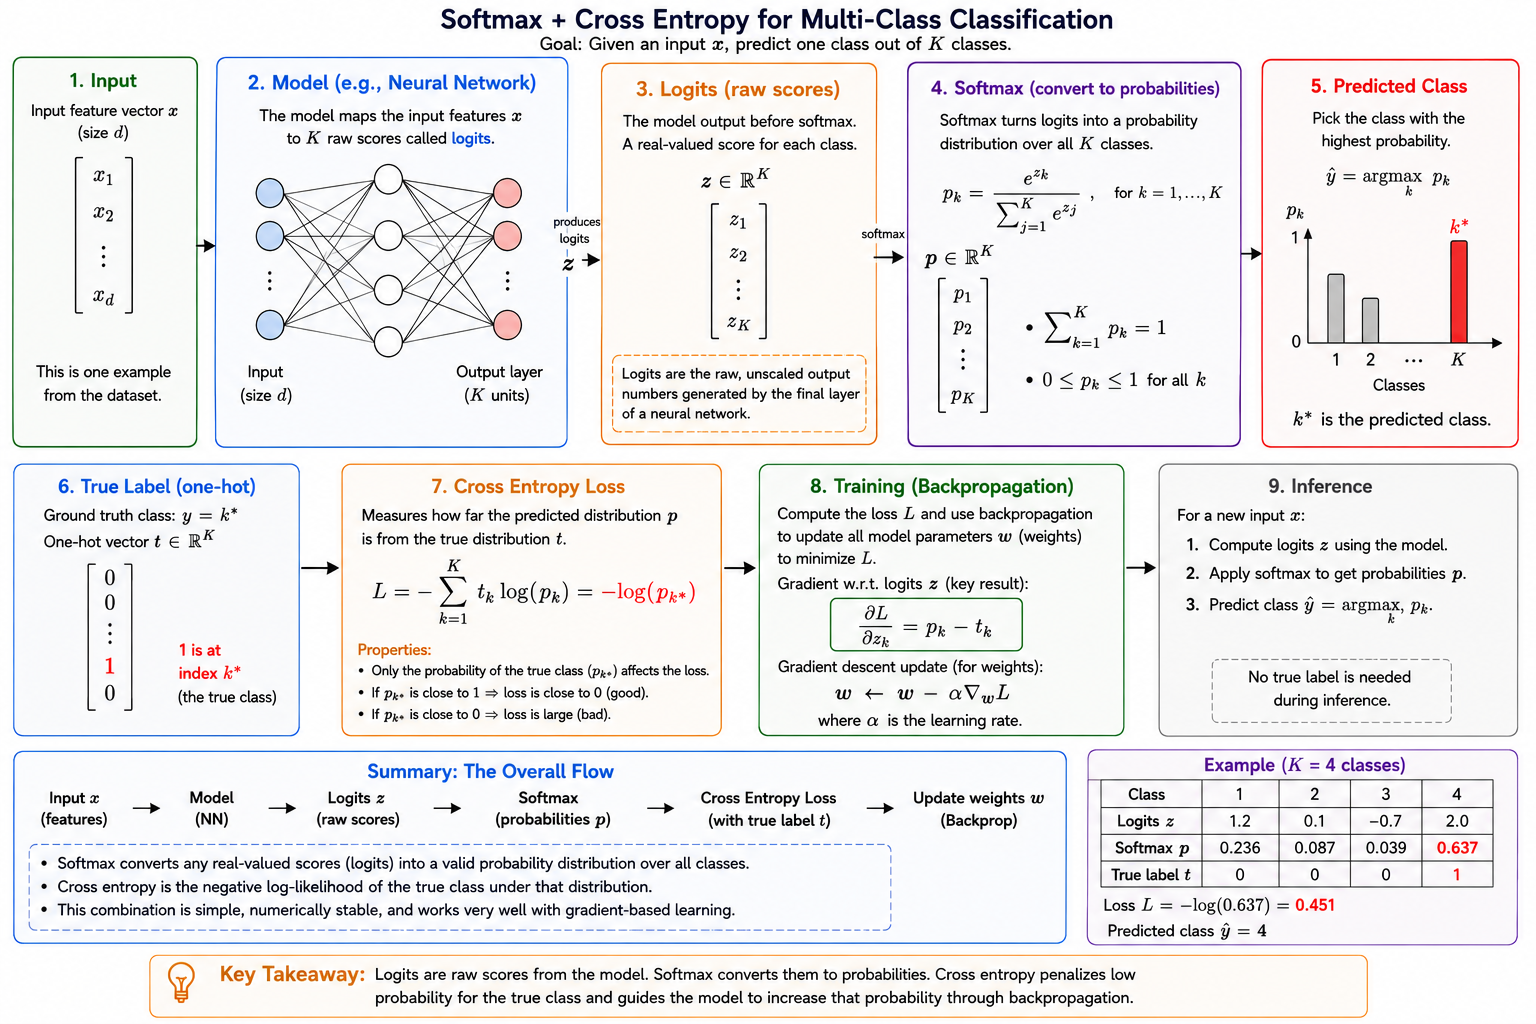

### **Softmax Activation Function** <a id="toc-softmax-activation-function"></a>


In a multi-class classifier, the final layer often produces one raw score for each class. These raw scores are called **logits**. A logit can be any real number, so logits are not probabilities yet.

The **Softmax activation function** converts a vector of logits into a probability distribution across the classes. Each output probability is between 0 and 1, and all class probabilities sum to 1.

Mathematically, Softmax is defined as:

$$
\sigma(\mathbf{z})_i =
\frac{e^{z_i}}
{\sum_{j=1}^{K} e^{z_j}}
$$

where:

- $\mathbf{z}$ is the vector of logits
- $z_i$ is the logit for class $i$
- $K$ is the total number of classes
- $e^{z_i}$ applies the exponential function to each logit

A larger logit produces a larger probability after Softmax. The image above shows this with a four-class example: the largest logit receives the highest probability, while the probabilities still sum to 1.

Softmax itself does not train the model. It prepares the model output so a loss function, such as categorical cross-entropy, can compare predicted probabilities with the true label.


### **One-Hot Encoding** <a id="toc-one-hot-encoding"></a>


Categorical cross-entropy expects the true label to be in the same class-position format as the prediction. When labels are stored as category names or class IDs, we convert them to **one-hot encoded** vectors.

A one-hot vector has one position for each class. The correct class is marked with 1, and every other class is marked with 0.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module3/L1/ohe_labels.png" style="width: 50%">


For example, in the four-class example shown above, the label for dog is represented as `[1, 0, 0, 0]`. This means the true probability is 1 for dog and 0 for the other classes.


### **Back to Categorical Cross-Entropy** <a id="toc-back-to-categorical-cross-entropy"></a>


Now we can connect the two pieces:

- Softmax gives the model's predicted probabilities $S$
- one-hot encoding gives the true label vector $T$
- categorical cross-entropy compares $S$ with $T$

Mathematically, the loss is defined as:

$$
L_{CE} = - \sum_{i=1}^{K} T_i \log(S_i)
$$

where:

- $T_i$ is the true label value from the one-hot encoded vector
- $S_i$ is the predicted probability from Softmax
- $K$ is the number of classes
- $\log$ is the logarithm function

Because a one-hot label contains zeros for the incorrect classes, only the predicted probability assigned to the correct class contributes to the final value. In the image above, the correct class is dog and the model assigns dog a probability of 0.775, so the loss becomes:

$$
L_{CE} = -(1 \cdot \log(0.775))
$$

$$
\approx 0.255
$$

A higher predicted probability for the correct class gives a smaller loss. A lower predicted probability for the correct class gives a larger loss.

In Keras, set `from_logits=False` when the final layer already uses `activation="softmax"`. Set `from_logits=True` only when the final layer returns raw logits without a Softmax activation.

## **Binary vs. Multi-Class Classification** <a id="toc-binary-vs-multi-class-classification"></a>


Now, let us do a quick review of binary and multi-class classification. Binary classification tasks require that all examples be assigned to one of two classes, whereas in multi-class classification, examples can belong to more than two classes.

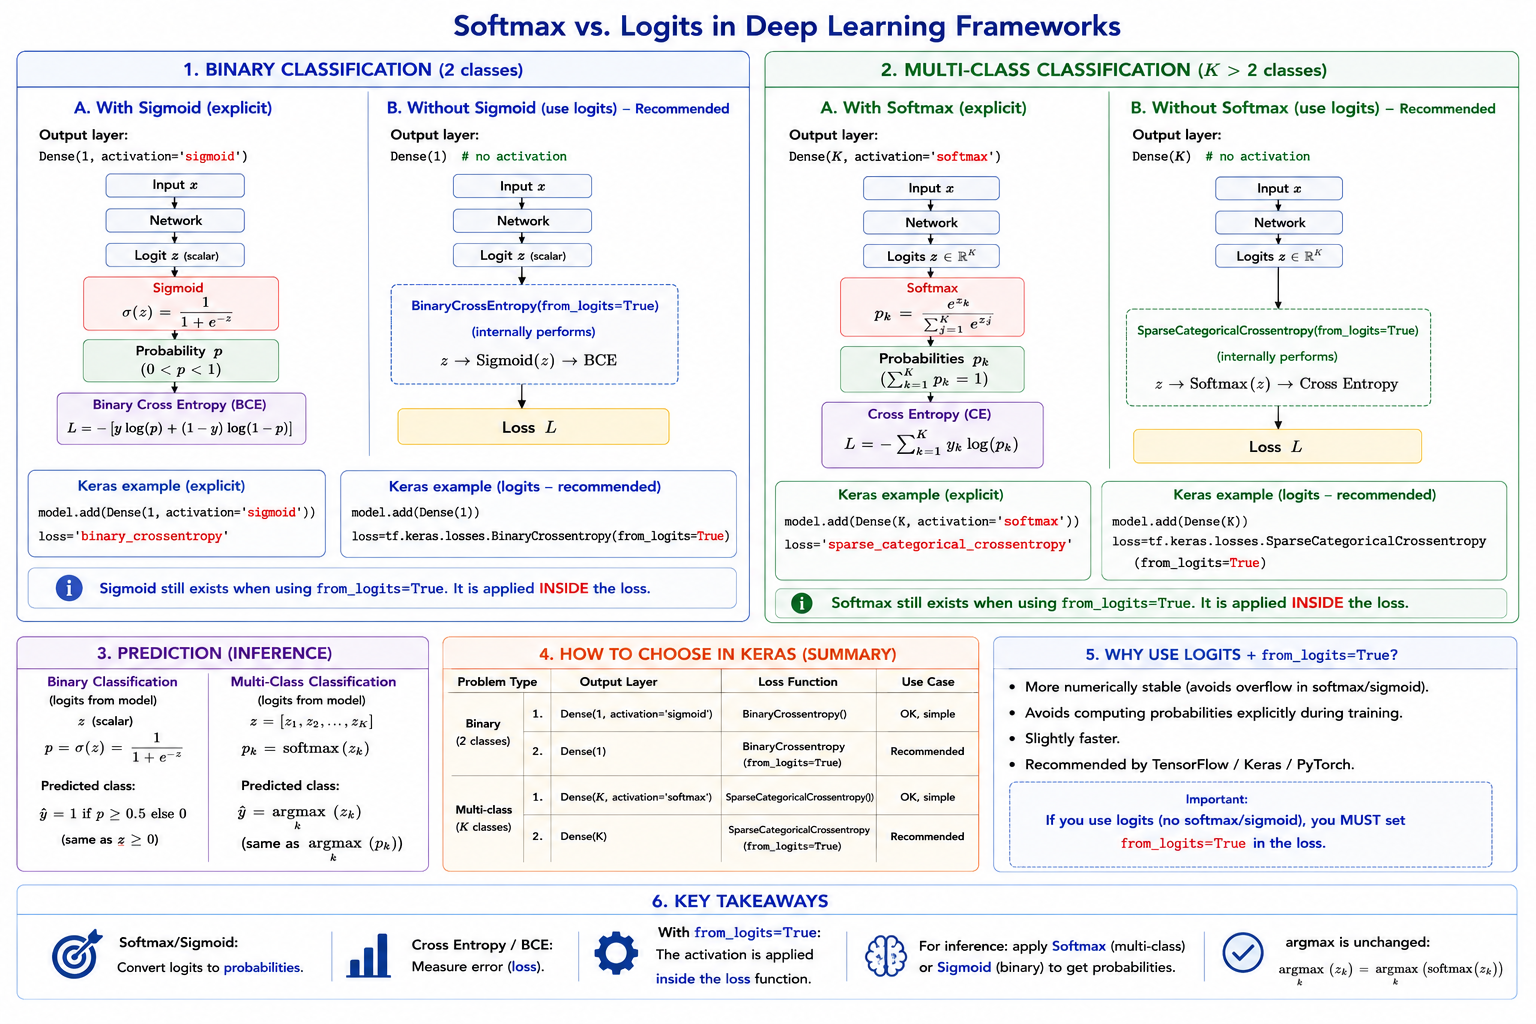

For binary classification problems, we have a final layer with a single node and a sigmoid activation function. It can map the output vector from a CNN to values between 0 and 1 before loss computations. The sigmoid function is denoted using the following formula:

$$\sigma(x) = 1/(1+e^{-x})$$


Let's see binary classification and multi-class classification in action.


### **Binary Classification** <a id="toc-binary-classification"></a>


Using a helper function defined at the beginning of the notebook, we will use the `make_blobs()` function from `sklearn` to generate isotropic Gaussian blobs for classification.

We will create a data set with 1000 samples, and use 750 of those samples for training a simple CNN model.


Let us define a few more configuration options.


*   **num_samples**: refers to the total number of samples in our dataset
*   **test_split**: refers to the number of samples to be used for testing
*   **cluster_centers**: we define 2 centers for our isotropic Gaussian blobs
*   **num_classes**: we have 2 classes
*   **loss_function_used**: since this is a binary classification problem, we use binary cross-entropy loss


In [ ]:
num_samples = 1000
test_split = 250
cluster_centers = [(15, 0), (30, 15)]
num_classes = len(cluster_centers)
loss_function_used = BinaryCrossentropy(from_logits=True)

In [ ]:
X_training, Targets_training, X_testing, Targets_testing = (
    generate_binary_blobs(num_samples, test_split)
)

We can take look at one of the samples.


In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(X_training[:, 0], X_training[:, 1])
plt.title("Linearly separable data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

We will build a simple CNN model with two hidden layers, that uses sigmoid as the activation function, and binary cross-entropy as the loss function. Let's define the architecture of our model:


In [ ]:
feature_vector_shape = X_training.shape[1]
input_shape = (feature_vector_shape,)

model = Sequential()
model.add(
    Dense(
        12,
        input_shape=input_shape,
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"],
)
history = model.fit(
    X_training,
    Targets_training,
    epochs=30,
    batch_size=5,
    verbose=1,
    validation_split=0.2,
)

We will now use the trained model to make predictions on an unseen test dataset.


In [ ]:
test_results = model.evaluate(X_testing, Targets_testing, verbose=1)
print(
    f"Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%"
)

In [ ]:
plot_decision_regions(X_testing, Targets_testing, clf=model, legend=2)
plt.figure(figsize=(4, 4))
plt.show()

The model successfully classifies the two clusters into two classes.


### **Multi-Class Classification** <a id="toc-multi-class-classification"></a>


Similar to binary classification, let's create another data set with 1000 samples, and use 750 of those samples for training a simple CNN model.


Let us define a few more configuration options.


*   **num_samples**: refers to the total number of samples in our dataset
*   **test_split**: refers to the number of samples to be used for testing
*   **cluster_centers**: we define 3 centers for our isotropic Gaussian blobs
*   **num_classes**: we have 3 classes
*   **loss_function_used**: since this is a multi-class classification problem, we use categorical cross-entropy loss

Important note about `from_logits` in `CategoricalCrossentropy`: 
If your final layer already uses:
```python
activation="softmax"
```
then use:
```python
from_logits=False
```
(default behavior).

If your final layer has NO softmax:
```python
Dense(num_classes)
```
then use:
```python
from_logits=True
```
because the outputs are raw logits, not probabilities.

In [ ]:
num_samples = 1000
train_split = 250
cluster_centers = [(-10, 5), (0, 0), (10, 5)]
num_classes = len(cluster_centers)
loss_function_used = CategoricalCrossentropy(from_logits=False)

In [ ]:
X_training, Targets_training, X_testing, Targets_testing = (
    generate_multiclass_blobs(
        num_samples, train_split, cluster_centers, num_classes
    )
)

Let's take a look at one of the samples.


In [ ]:
plt.scatter(X_training[:, 0], X_training[:, 1])
plt.title("Linearly separable data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

We will build a simple CNN model with two hidden layers, that uses softmax as the activation function, and categorical cross-entropy as the loss function. Let's define the architecture of our model:


In [ ]:
feature_vector_shape = X_training.shape[1]
input_shape = (feature_vector_shape,)

model = Sequential()
model.add(
    Dense(
        12,  # number of neurons in the first hidden layer
        input_shape=input_shape,
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(num_classes, activation="softmax"))

In [ ]:
model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
history = model.fit(
    X_training,
    Targets_training,
    epochs=30,
    batch_size=5,
    verbose=1,
    validation_split=0.2,
)

We will now use the trained model to make predictions on an unseen test dataset.


In [ ]:
test_results = model.evaluate(X_testing, Targets_testing, verbose=1)
print(
    f"Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%"
)

In [ ]:
class Onehot2Int(object):

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X)
        return np.argmax(y_pred, axis=1)


# fit keras_model
keras_model_no_ohe = Onehot2Int(model)

In [ ]:
# Plot decision boundary
plot_decision_regions(
    X_testing,
    np.argmax(Targets_testing, axis=1),
    clf=keras_model_no_ohe,
    legend=3,
)
plt.show()

## **Example: MNIST Hand-Written Digits** <a id="toc-example-mnist-hand-written-digits"></a>


Let us first load our MNIST hand-written dataset using the Keras library.


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

Now we can plot some sample digits from the training set.


In [ ]:
plt.rcParams["figure.figsize"] = (6, 6)

for i in range(4):
    plt.subplot(2, 2, i + 1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap="gray", interpolation="none")
    plt.title("class {}".format(y_train[num]))

plt.tight_layout()

Each image is on a grayscale (that is, only 1 channel) and is of size 28x28. We need to flatten each image by reshaping our matrix from 28x28 to a 784-length vector.


In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1] * X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])

print(X_train.shape)
print(X_test.shape)

Next, we need to change integers to 32-bit floating point numbers. We would also need to normalize our input to be in the range [0, 1], rather than [0-255].


In [ ]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train /= 255
X_test /= 255

Our target variable, `y`, is an array of the following form:


In [ ]:
y_train

**The categorical cross-entropy function expects that we provide one-hot encoded representations of the labels and predictions.** Let us one-hot encode our target, `y`, using the `OneHotEncoder()` function from sklearn.


`.reshape(-1, 1)` transforms an array into a single column with as many rows as necessary.
[0,1,2,1,0] into 
[[0],
 [1],
 [2],
 [1],
 [0]]

In [ ]:
enc = OneHotEncoder(sparse_output=False)
enc.fit(y_train.reshape(-1, 1))
print(enc.categories_)

In [ ]:
y_train_enc = enc.transform(y_train.reshape(-1, 1))
y_test_enc = enc.transform(y_test.reshape(-1, 1))

In this multi-class classification problem, the model predicts one probability for each of the 10 digit classes. We will use the same pairing introduced earlier:

- **Softmax** in the output layer to produce class probabilities
- **Categorical cross-entropy** to compare those probabilities with one-hot encoded labels


In [ ]:
feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used = CategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(
    Dense(
        12,
        input_shape=input_shape,
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(num_classes, activation="softmax"))

In [ ]:
model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train_enc,
    epochs=25,
    batch_size=5,
    verbose=1,
    validation_split=0.2,
)

In [ ]:
test_results = model.evaluate(X_test, y_test_enc, verbose=1)
print(
    f"Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%"
)

## **Example: Single-Digit House Number Recognition** <a id="toc-example-single-digit-house-number-recognition"></a>


Recognizing multi-digit text from photographs is a hard problem. In this example, we deal with a simpler sub-problem that involves using a convolutional neural network with the categorical cross-entropy loss function to build a classifier that identifies single-digit numbers from custom images.

First, let's load in a custom image using a URL. \[Image from [comforthouse](https://www.comforthouse.com/floating-1-number-sign.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01).]


In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/house_number_5.jpeg"
image = Image.open(urlopen(URL)).convert("RGB")
image

Let us define a CNN architecture that is similar to one used for MNIST hand-written digit classification. We use a softmax as the activation function and categorical cross-entropy as the loss function as this is a multi-class classification problem.


In [ ]:
feature_vector_shape, input_shape = 784, 784
num_classes = 10
loss_function_used = CategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(
    Dense(
        12,
        input_shape=(input_shape,),
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
history = model.fit(
    X_train,
    y_train_enc,
    epochs=25,
    batch_size=5,
    verbose=1,
    validation_split=0.2,
)

We must now pre-process our raw input images to be grayscale and 28x28 in size.


In [ ]:
img_rows, img_cols = 28, 28
img = Image.fromarray(np.uint8(image)).convert("L")
img_gray = img.resize((img_rows, img_cols), Image.Resampling.LANCZOS)
img_gray

We will now convert the image to an array, and reshape it such that it has a dimension of (1, 784).


In [ ]:
arr = np.array(img_gray)
arr = arr.reshape((img_cols * img_rows))
arr = np.expand_dims(arr, axis=0)

Finally, we will feed the array as an input to our model, and use the argmax function to determine the most likely digit label.


In [ ]:
prediction = model.predict(arr)
np.argmax(prediction)

We got it right! You are free to experiment with different custom images by simply changing the URL.


## **Exercises** <a id="toc-exercises"></a>


For these exercises, we will be using the Fashion-MNIST dataset. It consists of 60,000 28x28 grayscale training images and 10,000 test images for 10 different categories, listed below:


0.  T-shirt
1.  Trouser
2.  Pullover
3.  Dress
4.  Coat
5.  Sandal
6.  Shirt
7.  Sneaker
8.  Bag
9.  Ankle boot


### **Exercise 1 - Loading and plotting the images** <a id="toc-exercise-1-loading-and-plotting-the-images"></a>


Similar to the MNIST hand-written digits dataset, Fashion-MNIST is available for loading through Keras. Load the dataset using Keras in a similar manner. Plot some sample images from the training set.


In [ ]:
# Enter your solution here
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


plt.rcParams["figure.figsize"] = (6, 6)

for i in range(4):
    plt.subplot(2, 2, i + 1)
    num = random.randint(
        0, len(X_train)
    )  # picks a random index between 0 and 59999
    plt.imshow(X_train[num], cmap="gray", interpolation="none")
    plt.title("class {}".format(y_train[num]))

plt.tight_layout()

### **Exercise 2 - Preparing the data** <a id="toc-exercise-2-preparing-the-data"></a>


Convert all grayscale images of size 28x28 to a 784-length vector. Change integers to 32-bit floating point numbers and normalize the input to be in the range \[0, 1], rather than \[0-255].


In [ ]:
# Enter your solution here
X_train = X_train.reshape(
    X_train.shape[0], X_train.shape[1] * X_train.shape[2]
)  # reshape the 3D array into a 2D array of shape (60000, 784)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[2])

print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train /= 255
X_test /= 255

### **Exercise 3 - One-hot encoding** <a id="toc-exercise-3-one-hot-encoding"></a>


Create one-hot encoded representations of the target variable using the `OneHotEncoder()` function from sklearn.
For example:
```
0 → [1,0,0]
1 → [0,1,0]
2 → [0,0,1]
```

In [ ]:
# Enter your solution here
enc = OneHotEncoder(
    sparse_output=False
)  # create an instance of the OneHotEncoder class with sparse=False to return a dense array
enc.fit(y_train.reshape(-1, 1))
print(enc.categories_)

y_train_enc = enc.transform(y_train.reshape(-1, 1))
y_test_enc = enc.transform(y_test.reshape(-1, 1))

### **Exercise 4 - Build model architecture** <a id="toc-exercise-4-build-model-architecture"></a>


Build a CNN model with 2 hidden layers, that uses softmax as the activation function, and categorical cross-entropy as the loss function.


In [ ]:
# Enter your solution here

feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used = CategoricalCrossentropy(from_logits=False)

model = Sequential()
model.add(
    Dense(
        12,
        input_shape=input_shape,
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
history = model.fit(
    X_train,
    y_train_enc,
    epochs=25,
    batch_size=5,
    verbose=1,
    validation_split=0.2,
)

test_results = model.evaluate(X_test, y_test_enc, verbose=1)
print(
    f"Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%"
)

### **(Optional) Exercise 5 - Sparse Categorical Cross Entropy** <a id="toc-optional-exercise-5-sparse-categorical-cross-entropy"></a>


Earlier, we used categorical cross-entropy with one-hot encoded labels. Keras also provides sparse categorical cross-entropy, which lets us keep each label as an integer class index instead of converting it to a one-hot vector.

For example, if the correct class is index 3, categorical cross-entropy expects `[0, 0, 0, 1, 0]`, while sparse categorical cross-entropy expects `3`.

In this exercise, build a neural network with two hidden Dense layers. Use a softmax output layer for the 10 classes, and compile the model with sparse categorical cross-entropy. Because this loss expects integer class labels, use the original labels instead of one-hot encoded labels.


**SparseCategoricalCrossentropy vs. CategoricalCrossentropy**

Both loss functions are used for multi-class classification. The main difference is the label format passed to the model during training.

| Loss Function                     | Expected Label Format  | Example Label |
| --------------------------------- | ---------------------- | ------------- |
| `sparse_categorical_crossentropy` | Integer class labels   | `3`           |
| `categorical_crossentropy`        | One-hot encoded labels | `[0, 0, 0, 1, 0, ...]` |


In [ ]:
# Enter your solution here
feature_vector_shape = X_train.shape[1]
input_shape = (feature_vector_shape,)
num_classes = 10
loss_function_used = SparseCategoricalCrossentropy()

model = Sequential()
model.add(
    Dense(
        12,
        input_shape=input_shape,
        activation="relu",
        kernel_initializer="he_uniform",
    )
)
model.add(Dense(8, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(num_classes, activation="softmax"))


model.compile(
    loss=loss_function_used,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)
history = model.fit(
    X_train, y_train, epochs=25, batch_size=5, verbose=1, validation_split=0.2
)

test_results = model.evaluate(X_test, y_test, verbose=1)
print(
    f"Test results - Loss: {test_results[0]} - Accuracy: {test_results[1]*100}%"
)

## **References**


Bishop, C., 2006. Pattern Recognition and Machine Learning.


## **Authors**


[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2022-05-20|0.1|Kopal Garg|Create Lab|
|2022-09-06|0.1|Steve Hord|QA pass edits|
| 2026-05-19        | 0.2     | Su Wu| Documentation edit    |


Copyright © 2022 IBM Corporation. All rights reserved.
